
 Entropy
Accuracy : 0.9649
F1 Score : 0.9725


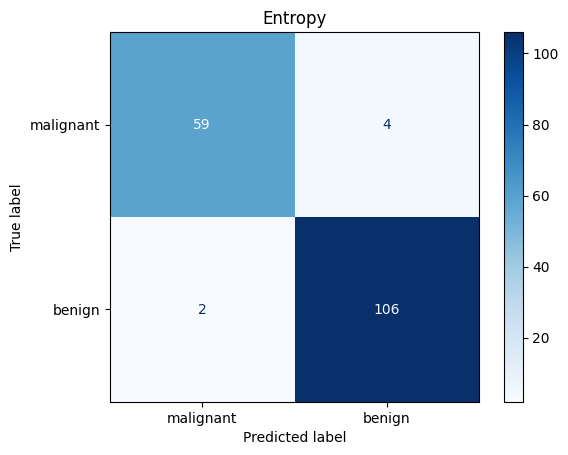


 Gini
Accuracy : 0.9415
F1 Score : 0.9528


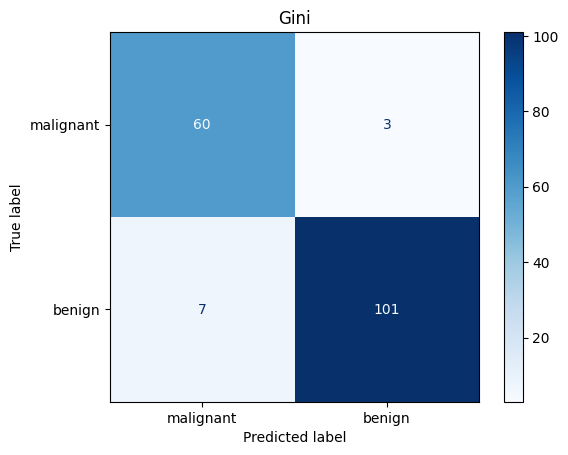


 Entropy Depth=3
Accuracy : 0.9708
F1 Score : 0.9772


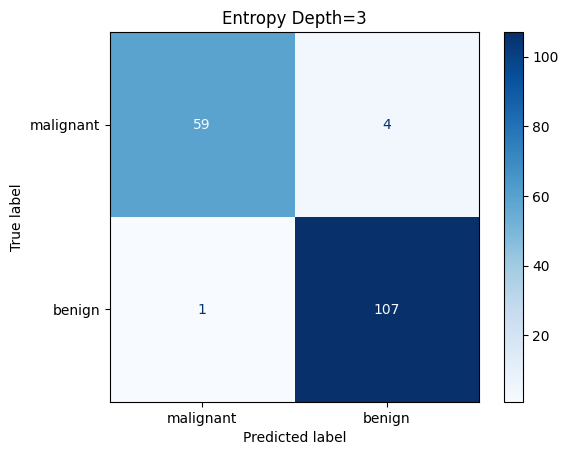


 Gini Depth=3
Accuracy : 0.9649
F1 Score : 0.9725


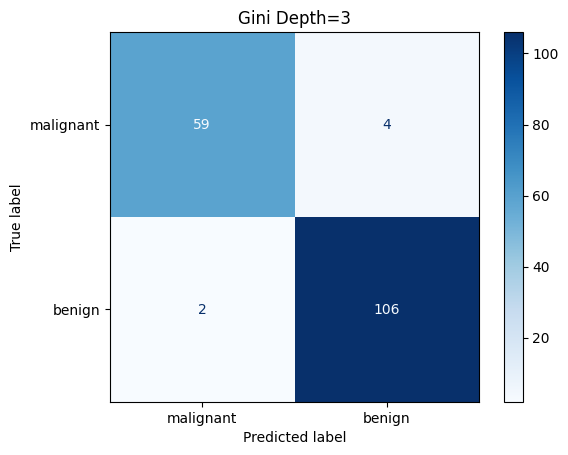


 Entropy Pruned
Accuracy : 0.9649
F1 Score : 0.9725


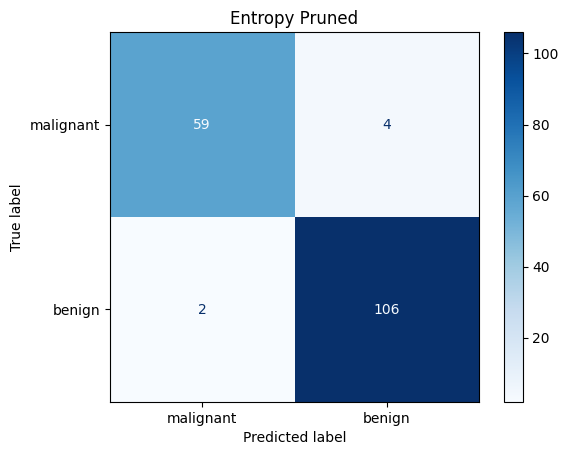


 Gini Pruned
Accuracy : 0.9649
F1 Score : 0.9722


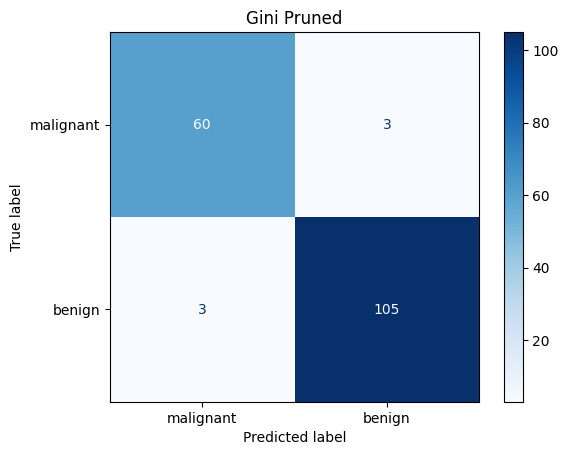

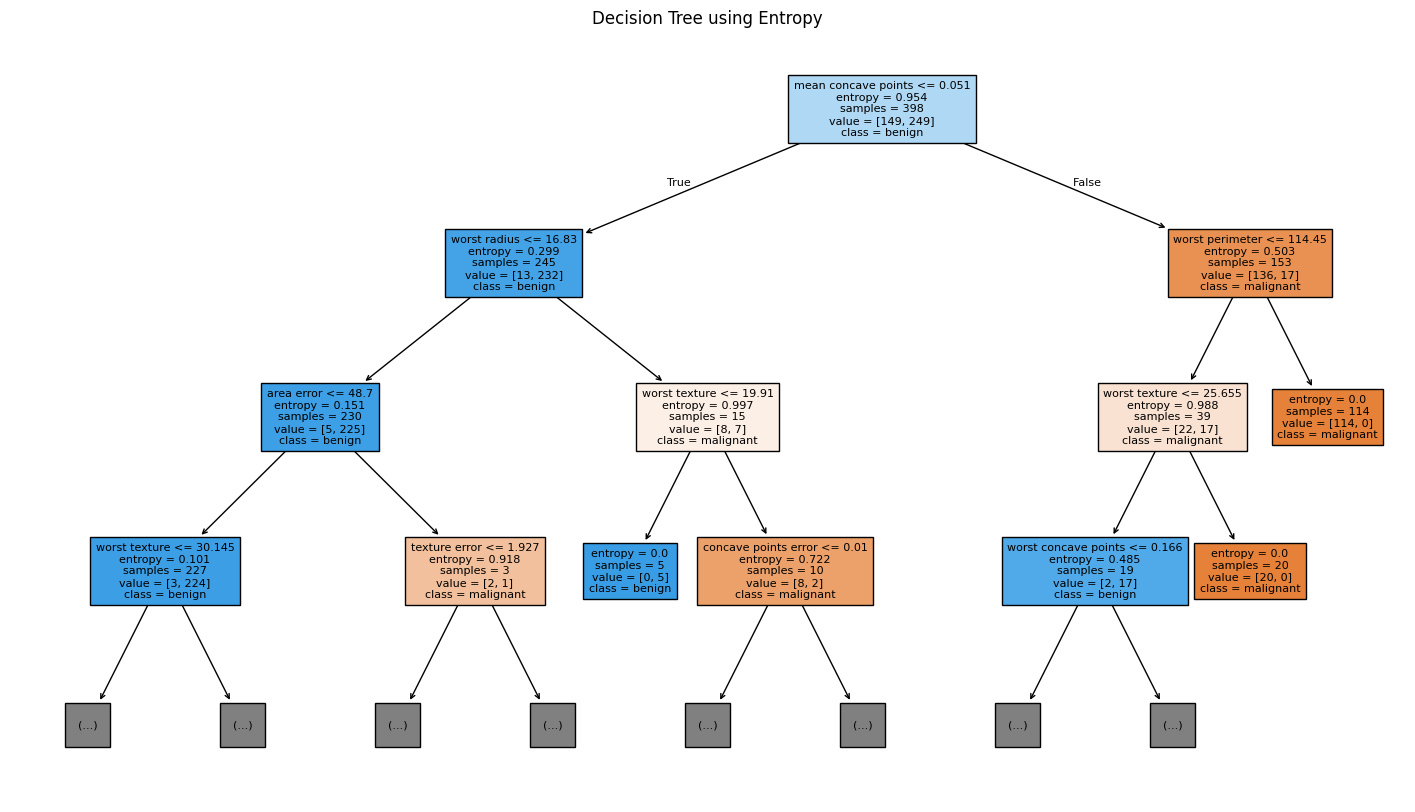

In [3]:
# Decision Tree Classifier - Entropy vs Gini Index

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Load Built-in Dataset
data = load_breast_cancer()

X = data.data
y = data.target

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42
)

# Different Configurations
models = {
    "Entropy": DecisionTreeClassifier(criterion="entropy", random_state=42),
    "Gini": DecisionTreeClassifier(criterion="gini", random_state=42),
    "Entropy Depth=3": DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=42),
    "Gini Depth=3": DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=42),
    "Entropy Pruned": DecisionTreeClassifier(criterion="entropy", ccp_alpha=0.01, random_state=42),
    "Gini Pruned": DecisionTreeClassifier(criterion="gini", ccp_alpha=0.01, random_state=42)
}

print("="*65)

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    print("\n",name)
    print("Accuracy :",round(acc,4))
    print("F1 Score :",round(f1,4))

    cm = confusion_matrix(y_test,y_pred)

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=data.target_names
    ).plot(cmap="Blues")

    plt.title(name)
    plt.show()

# Display Decision Tree (Entropy)
plt.figure(figsize=(18,10))

plot_tree(
    models["Entropy"],
    max_depth=3,
    filled=True,
    fontsize=8,
    feature_names=data.feature_names,
    class_names=data.target_names
)

plt.title("Decision Tree using Entropy")
plt.show()